# Project Medical Cost
##### tala

## Import Libraries

In [ ]:
import pandas as pd # work with data
import numpy as np # use calculatons
import seaborn as sns # use to draw graphs
import matplotlib.pyplot as plt # use ploting graphs

## DataBase

In [ ]:
df = pd.read_csv("/content/insurance.csv") #read the database

In [ ]:
def check_data(df): #explore data
  print("\033[94m________________________First 5 rows________________________\033[0m :\n", df.head()) #show first 5 rows to make sure data read correctly
  print("\033[94m________________________last 5 rows________________________\033[0m :\n", df.tail()) #show last 5 rows to make sure there no problem
  print("\033[94m________________________shape of data________________________\033[0m :\n", df.shape)#show num of columns and rows (row,col)
  print("\033[94m________________________info of data________________________\033[0m :\n")#print text explains the following code
  df.info() #to know informaion about data
  print("\033[94m________________________data statistics________________________\033[0m:\n", df.describe())#show data statistics
  print("\033[94m________________________value counts of smoker________________________\033[0m:\n",df['smoker'].value_counts())#show number of value in smoker
  print("\033[94m________________________value counts of region________________________\033[0m:\n",df['region'].value_counts())#show number of value in region
check_data(df) #call the function
#\033[94m start print test in blue
#\033[0m stop print text in blue
# I use blue color for clarity

________________________First 5 rows________________________ :
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
________________________last 5 rows________________________ :
       age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603
________________________shape of data________________________ :
 (1338, 7)
________________________

## Convert Data Type

In [ ]:
def data_type(df): #convert col to the right type
  df = df.copy() # copy data so that if we have an error it won't affect the data itself
  df["sex"] = df["sex"].astype("category") # convert type from object to category
  df["smoker"] = df["smoker"].astype("category")# convert type from object to category
  df["region"] = df["region"].astype("category")# convert type from object to category
  return df #return the dataframe

## Find missing value

In [ ]:
def missing_data(df): # check missing value
  print("\033[94m________________________total of missing value________________________\033[0m:\n", df.isnull().sum()) # find total of missing value
  return df #return the dataframe
missing_data(df) #call the function
#we dont have any missing value so no action is needed

________________________total of missing value________________________:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Handle Duplicates

In [ ]:
def drop_dupl(df): #remove duplicate rows
  df = df.copy() # copy data so that if we have an error it won't affect the data itself
  print("\033[94m________________________total of duplicated befor cleaning________________________\033[0m:\n",df.duplicated().sum())#total of duplicated befor cleaning
  df = df.drop_duplicates()#drop duplicates rows form the dataset
  print("\033[94m________________________total of duplicated after cleaning________________________\033[0m:\n",df.duplicated().sum())#total of duplicated after cleaning
  return df #return the dataframe
drop_dupl(df) #call the function

________________________total of duplicated befor cleaning________________________:
 1
________________________total of duplicated after cleaning________________________:
 0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## plots

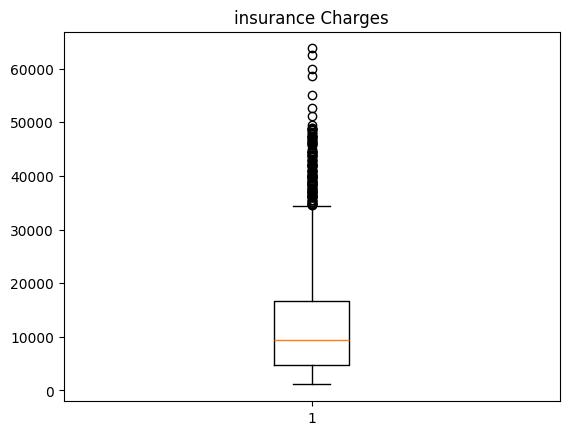

In [ ]:
def plot(): #draw boxplot to data outliers
  plt.boxplot(x=df['charges']) #draw boxplot to find outlires in charges
  plt.title("insurance Charges") #print in plot title
  plt.show() #print the boxplot
plot() #call the function

## hendling outliers

In [ ]:
def handle_outlires(df): #handle outlires by capping
  charges99 = df['charges'].quantile(0.99) #get 99th percentile
  df["charges"] = df['charges'].clip(upper=charges99) #cap value above 99th percentile
  return df #return the dataframe

## cheks

In [ ]:
def check_data(df):
  assert df["age"].min() >=0, "negative age found" #make sure there are no negative num in col age
  assert df["charges"].notna().all(),"charges still has NaN" #make sure we dont have missing value in charges
  assert df.shape[1] == 7, "inorrect num of col" #check the dataset has 7 col
  return df #return the dataframe
check_data(df) #call the function

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Function Call

________________________total of missing value________________________:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
________________________total of duplicated befor cleaning________________________:
 1
________________________total of duplicated after cleaning________________________:
 0


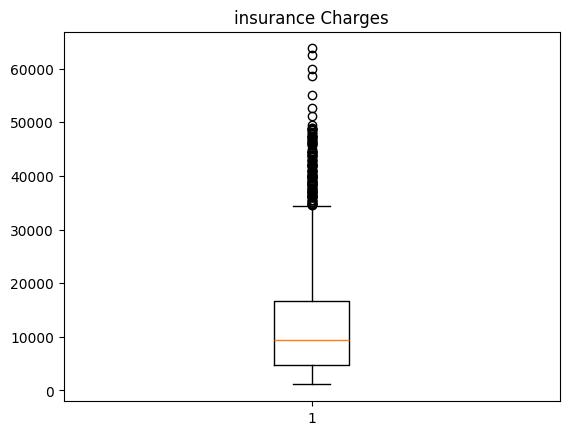

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1337 rows x 7 columns]


In [ ]:
def clean_data(df):
  check_data(df) #call the function
  df = data_type(df) #call the function
  df = missing_data(df) #call the function
  df = drop_dupl(df) #call the function
  plot() #call the function
  df = handle_outlires(df) #call the function
  df = check_data(df) #call the function
  return df #return the dataframe
print(clean_data(df)) #print the function

________________________total of missing value________________________:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
________________________total of duplicated befor cleaning________________________:
 1
________________________total of duplicated after cleaning________________________:
 0


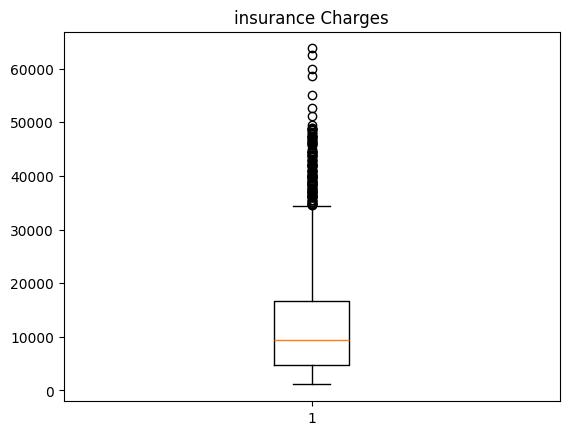

In [ ]:
df = pd.read_csv("insurance.csv")  # read data
df = clean_data(df)  # clean data
df.to_csv("cleaned_insurance.csv", index=False)  # save cleaned data

In [ ]:
df.to_csv("cleaned_insurance.csv", index=False) # to save dataset after cleaning to import in another